In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from tensorflow import keras

In [ ]:
Fashion_data=keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
Fashion_data

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
#performance metrics modules
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
#splitting Raw data
(X_train_sp,y_train_sp),(X_test_sp,y_test_sp)=Fashion_data

In [ ]:
X_train_sp.shape

(60000, 28, 28)

In [ ]:
X_test_sp.shape

(10000, 28, 28)

In [ ]:
#Fashion items labels
items_names = ["T-shirt/top", "Trouser", "Pullover", "Dress",
               "Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
items_names


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
#Reshaping data
X_train_sp=X_train_sp.reshape((60000,28,28,1))
X_test_sp=X_test_sp.reshape((10000,28,28,1))
X_train_sp.shape

(60000, 28, 28, 1)

In [ ]:
#Normalising data
x_train_norm = X_train_sp / 255
x_test_norm = X_test_sp / 255

In [ ]:
#Data splitingfor training and testing and validation
x_validate, x_train = x_train_norm[:5000], x_train_norm[5000:]
y_validate, y_train = y_train_sp[:5000], y_train_sp[5000:]
x_test= x_test_norm

In [ ]:
y_train.shape

(55000,)

In [ ]:
#Random seed
tf.random.set_seed(42)
#Model Architecture
model=keras.models.Sequential()
#Building model
model.add(keras.layers.Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),padding='valid',activation='relu',input_shape=(28,28,1)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(300,activation='relu'))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))

#Model Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     1,622,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,654,130 (6.31 MB)

 Trainable params: 1,654,130 (6.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.6963 - loss: 0.8942 - val_accuracy: 0.7298 - val_loss: 0.7681
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8009 - loss: 0.5462 - val_accuracy: 0.7790 - val_loss: 0.6223
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.8253 - loss: 0.4852 - val_accuracy: 0.8056 - val_loss: 0.5498
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.8391 - loss: 0.4476 - val_accuracy: 0.8186 - val_loss: 0.5050
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.8491 - loss: 0.4198 - val_accuracy: 0.8282 - val_loss: 0.4701


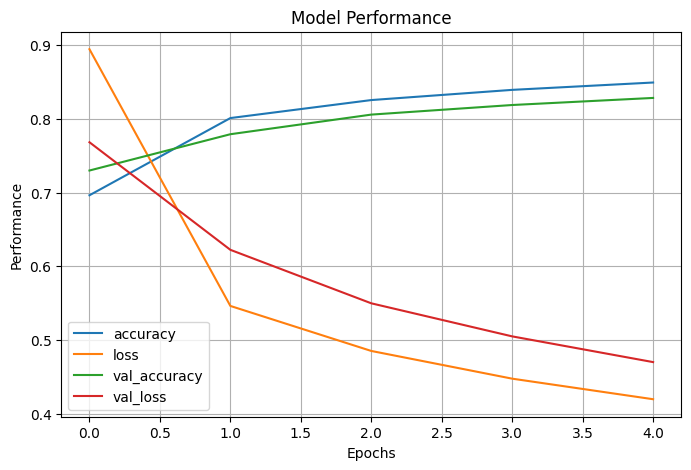

In [ ]:
# Compiling the model
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])

# Fitting Values to Model
model_fit = model.fit(x_train, y_train, epochs=5, batch_size=64,
                      validation_data=(x_validate, y_validate))

# Model Performance Visualization
pd.DataFrame(model_fit.history).plot(figsize=(8, 5))
plt.title('Model Performance')
plt.xlabel('Epochs')
plt.ylabel('Performance')
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8075 - loss: 0.5225
Model Evaluation Score : [0.5224615335464478, 0.8075000047683716]
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
y_pred output : [9 2 1 ... 8 1 5]
Predicted Class :  [9 2 1]
Predicted Class in Labels :  ['Ankle boot' 'Pullover' 'Trouser']


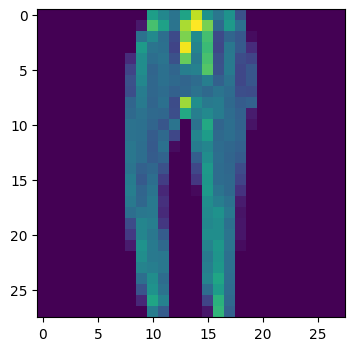

Confusion Matrix : 
 [[477   4  68  43  25   2 368   0  13   0]
 [  0 955   3  27  10   0   4   0   1   0]
 [  3   1 776   5 195   1  16   0   3   0]
 [  1  17  36 762 127   0  52   0   5   0]
 [  0   0  75   4 902   0  16   0   3   0]
 [  0   0   0   1   0 921   0  52   2  24]
 [ 34   1 201  18 268   0 457   0  21   0]
 [  0   0   0   0   0  22   0 928   1  49]
 [  0   1  32   7  13   2   2   6 937   0]
 [  0   0   0   0   0   7   0  32   1 960]]
Accuracy Score :  0.8075
Classification Report : 
               precision    recall  f1-score   support

           0       0.93      0.48      0.63      1000
           1       0.98      0.95      0.97      1000
           2       0.65      0.78      0.71      1000
           3       0.88      0.76      0.82      1000
           4       0.59      0.90      0.71      1000
           5       0.96      0.92      0.94      1000
           6       0.50      0.46      0.48      1000
           7       0.91      0.93      0.92      1000
          

In [ ]:
# Model Evaluation
score = model.evaluate(x_test, y_test_sp)
print('Model Evaluation Score :', score)

# Prediction & Class Output
y_pred = np.argmax(model.predict(x_test), axis=-1)
print('y_pred output :', y_pred)

# Class & Labels of initial 3 data
print('Predicted Class : ', y_pred[:3])
print('Predicted Class in Labels : ', np.array(items_names)[y_pred[:3]])

# Predicted Output Visualization
plt.figure(figsize=(6, 4))
plt.imshow(x_test[80].reshape((28, 28)))
plt.show()

# Performance Metrics
# Confusion Matrix
print('Confusion Matrix : \n', confusion_matrix(y_test_sp, y_pred))

# Accuracy Score
print('Accuracy Score : ', accuracy_score(y_test_sp, y_pred))

# Classification Report
print('Classification Report : \n', classification_report(y_test_sp, y_pred))